# TEST CELLPOSE ON TRAIN SET

In [1]:
import os
import argparse
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from cellpose.models import CellposeModel

from provided_code.metric import score
from provided_code.generate_submission import build_submission
from generate_train_submission import build_submission as one_submission

from my_paths import *

In [2]:
def get_stats(x):
    print(f"MEAN: {np.mean(x)}")
    print(f"MEDIAN: {np.median(x)}")
    print(f"MIN: {np.min(x)}")
    print(f"MAX: {np.max(x)}")

def load_dax(filepath, height=2048, width=2048):
    """Load a .dax raw image file. Raw uint16 binary, no header."""
    raw = np.fromfile(filepath, dtype=np.uint16)
    n_frames = len(raw) // (height * width)
    return raw.reshape(n_frames, height, width)

def normalize(x):
    return (x - x.min()) / (x.max() - x.min()) 

In [3]:
epi_stack = load_dax(TRAIN /  'FOV_001/Epi-750s5-635s5-545s1-473s5-408s5_001.dax')
print(f'Epi stack shape: {epi_stack.shape}  (frames, height, width)')
z_plane = 2  # middle z-plane
dapi = epi_stack[6 + z_plane * 5]   # frame 16 for z2
polyt = epi_stack[5 + z_plane * 5]  # frame 15 for z2

Epi stack shape: (27, 2048, 2048)  (frames, height, width)


In [4]:
# Model evaluation

# Cellpose v4+: use CellposeModel (not models.Cellpose)
model = CellposeModel(model_type='nuclei', gpu=True)

# TODO: USE THE POLYT IMAGE DATA
# eval() returns 3 values: masks, flows, styles
masks, flows, styles = model.eval(dapi, diameter=30, channels=[0, 0])

model_type argument is not used in v4.0.1+. Ignoring this argument...
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


In [5]:
print(f'Segmentation complete!')
print(f'flows shape: {len(flows)}')
print(f'flows shape: {flows[0].shape}')
print(f'flows shape: {flows[1].shape}')
print(f'flows shape: {flows[2].shape}')
print(f'Mask shape: {masks.shape}')
print(f'Mask shape: {masks.shape}')
print(f'Number of cells found: {masks.max()}')

Segmentation complete!
flows shape: 3
flows shape: (2048, 2048, 3)
flows shape: (2, 2048, 2048)
flows shape: (2048, 2048)
Mask shape: (2048, 2048)
Mask shape: (2048, 2048)
Number of cells found: 218


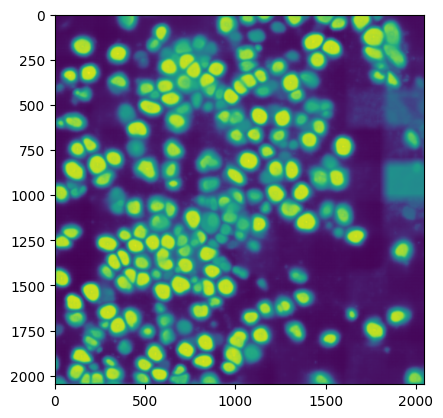

In [6]:
plt.imshow(flows[2])

In [7]:
# Save masks to file
np.save(RESULTS / 'FOV_001_mask.npy', masks)

## Plot Data

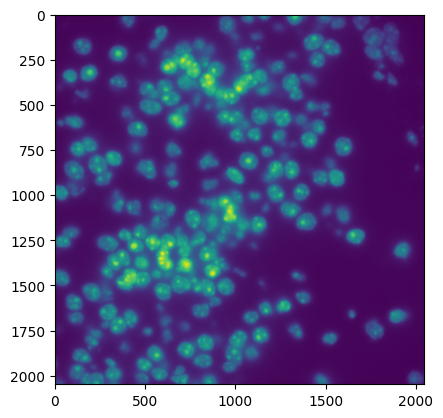

In [8]:
plt.imshow(dapi)

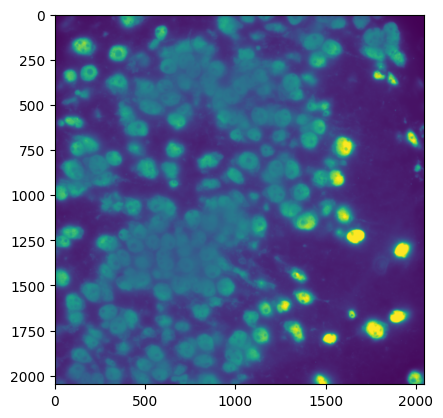

In [9]:
plt.imshow(polyt)

In [10]:
get_stats(polyt)
get_stats(dapi)
get_stats(normalize(polyt))
get_stats(normalize(dapi))

MEAN: 16961.89600610733
MEDIAN: 14369.0
MIN: 638
MAX: 65535
MEAN: 1621.180549621582
MEDIAN: 882.0
MIN: 53
MAX: 10201
MEAN: 0.251535448574007
MEDIAN: 0.21158142903369956
MIN: 0.0
MAX: 1.0
MEAN: 0.15453099621812988
MEDIAN: 0.08169097359085534
MIN: 0.0
MAX: 1.0


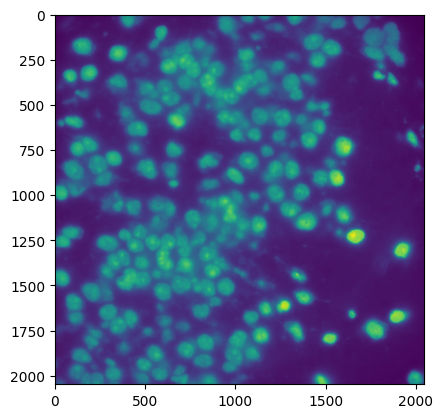

In [11]:
plt.imshow(0.5 * normalize(polyt) + 0.5 * normalize(dapi))

In [12]:
# !python3 generate_train_submission.py --mask_A FOV_001_mask.npy

## Load Spots Train CSV

In [13]:
spots_train_df = pd.read_csv(provided_code / 'spots_train.csv')
# Check to see the range of values
spots_train_df['global_x'].max(), spots_train_df['global_x'].min(), spots_train_df['global_x'].median(), spots_train_df['global_y'].max(), spots_train_df['global_y'].min(), spots_train_df['global_y'].median()

(np.float64(5798.334),
 np.float64(-2402.6602),
 np.float64(675.7866),
 np.float64(2647.3037),
 np.float64(-1953.6913),
 np.float64(746.13824))

In [14]:
spots_train_df.columns

Index(['barcode_id', 'fov', 'image_row', 'image_col', 'global_x', 'global_y',
       'global_z', 'x', 'y', 'target_gene'],
      dtype='object')

In [15]:
# spots_train_df = spots_train_df[spots_train_df['fov'] == 'FOV_001']
spots_train_df = spots_train_df[['fov', 'image_row', 'image_col', 'global_x', 'global_y', 'global_z']]
spots_train_df.head(4)

,fov,image_row,image_col,global_x,global_y,global_z
0,FOV_019,1468,1575,5649.4106,-393.08737,0.0
1,FOV_019,303,1800,5776.4834,-368.60250,0.0
2,FOV_019,749,579,5727.8633,-501.73105,0.0
3,FOV_019,1100,704,5689.5854,-488.09860,0.0


In [16]:
spots_train_df['fov'].value_counts()

fov
FOV_001    117893
FOV_025     96648
FOV_011     94166
FOV_020     93692
FOV_035     91610
FOV_017     88478
FOV_031     87881
FOV_006     83153
FOV_002     80581
FOV_012     78605
FOV_034     77318
FOV_022     77214
FOV_033     76323
FOV_003     73217
FOV_019     72619
FOV_004     71555
FOV_038     70272
FOV_007     68477
FOV_014     67028
FOV_009     63693
FOV_030     63345
FOV_039     62342
FOV_010     61579
FOV_040     60352
FOV_008     60136
FOV_021     56208
FOV_037     56089
FOV_032     55973
FOV_029     54886
FOV_013     54197
FOV_016     53516
FOV_018     52501
FOV_028     52472
FOV_015     52204
FOV_027     50633
FOV_036     50077
FOV_005     40010
FOV_024     32671
FOV_026     30165
FOV_023     29580
Name: count, dtype: int64

In [17]:
import torch
import gc
# 1. Delete large objects
# del model 
# 2. Force garbage collection
gc.collect()
# 3. Clear the PyTorch cache
torch.cuda.empty_cache()

## Load Test Set

In [18]:
# We need to recreate the spot_id column
test_spots_df = pd.read_csv(provided_code / 'test_spots.csv')
test_spots_df.columns

Index(['spot_id', 'fov', 'image_row', 'image_col', 'global_x', 'global_y',
       'global_z', 'target_gene'],
      dtype='object')

In [19]:
test_spots_df = test_spots_df[['spot_id', 'fov', 'image_row', 'image_col', 'global_x', 'global_y', 'global_z']]
test_spots_df.head(5)

,spot_id,fov,image_row,image_col,global_x,global_y,global_z
0,spot_0,FOV_B,1899,511,-1797.5458,90.93547,0.0
1,spot_1,FOV_B,812,140,-1679.0660,50.45134,0.0
2,spot_2,FOV_B,1913,190,-1799.0302,55.88918,0.0
3,spot_3,FOV_B,1275,734,-1729.5323,115.19051,0.0
4,spot_4,FOV_B,1297,765,-1731.9692,118.57968,0.0


## CALCULATE SCORE FROM 
- cell_boundaries_train.csv
- spots_train.csv


In [20]:
from tqdm import tqdm
from shapely.geometry import Point, Polygon

poly = Polygon([(0, 0), (1, 0), (1, 1), (0, 1)])
point = Point(0.5, 0.5)
print(poly.contains(point))  # Output: True

True


In [21]:
# Get cell boundries and convert from a string to a list

def parse_float_list(text):
    if isinstance(text, str):
        return np.fromstring(text, sep=',').tolist()
    return None

cell_boundaries_train_df = pd.read_csv(provided_code / 'cell_boundaries_train.csv')
cell_boundaries_train_df.iloc[:, 1:] = cell_boundaries_train_df.iloc[:, 1:].applymap(parse_float_list)

In [22]:
cell_boundaries_train_df.head(4)

,Unnamed: 0,boundaryX_z0,boundaryY_z0,boundaryX_z1,boundaryY_z1,boundaryX_z2,boundaryY_z2,boundaryX_z3,boundaryY_z3,boundaryX_z4,boundaryY_z4
0,267725525651232306728125526231708191,"[-1343.5731309860944, -1343.5731309860944, -13...","[-474.1219997406006, -474.230999737978, -474.3...","[-1343.5731309860944, -1343.5731309860944, -13...","[-473.9039997458458, -474.0129997432232, -474....","[-1343.6821309834718, -1343.6821309834718, -13...","[-473.03199976682663, -473.140999764204, -473....","[-1343.7911309808492, -1343.7911309808492, -13...","[-474.0129997432232, -474.1219997406006, -474....","[-1343.7911309808492, -1343.7911309808492, -13...","[-473.140999764204, -473.2499997615814, -473.3..."
1,327375991457903881984615241423065475,"[2189.4068658143283, 2189.4068658143283, 2189....","[-1787.903062850237, -1788.0120628476143, -178...","[2189.624865809083, 2189.624865809083, 2189.62...","[-1789.2110628187656, -1789.320062816143, -178...","[2189.4068658143283, 2189.4068658143283, 2189....","[-1788.6660628318787, -1788.775062829256, -178...","[2189.4068658143283, 2189.4068658143283, 2189....","[-1788.775062829256, -1788.8840628266335, -178...","[2189.624865809083, 2189.624865809083, 2189.62...","[-1788.4480628371239, -1788.5570628345013, -17..."
2,364755379140285267217928676041057312,"[-1336.3791311591863, -1336.3791311591863, -13...","[-533.744998306036, -533.8539983034134, -533.9...","[-1336.7061311513185, -1336.7061311513185, -13...","[-533.744998306036, -533.8539983034134, -533.9...","[-1334.5261312037705, -1334.5261312037705, -13...","[-531.6739983558655, -531.7829983532429, -531....","[-1333.3271312326192, -1333.338031232357, -133...","[-531.5649983584881, -531.5758983582258, -531....","[-1333.2181312352418, -1333.2181312352418, -13...","[-531.1289983689785, -531.2379983663559, -531...."
3,377956362916104527021675785082246047,"[174.90989572703836, 174.90989572703836, 174.9...","[2337.431938946247, 2337.3229389488697, 2337.2...","[174.58289573490617, 174.58289573490617, 174.5...","[2338.6309389173985, 2338.521938920021, 2338.4...","[174.255895742774, 174.255895742774, 174.25589...","[2338.3039389252663, 2338.194938927889, 2338.0...","[173.8198957532644, 173.8198957532644, 173.819...","[2337.3229389488697, 2337.2139389514923, 2337....","[173.8198957532644, 173.8198957532644, 173.819...","[2337.431938946247, 2337.3229389488697, 2337.2..."


In [23]:
# Get basic view
def get_first(x):
    if x:
        return x[0]
    return None
x_boundry_test = cell_boundaries_train_df['boundaryX_z2'].transform(get_first)
cell_boundaries_train_df.shape, x_boundry_test.min(), x_boundry_test.max(), x_boundry_test.median()


((4082, 11),
 np.float64(-2413.780029296875),
 np.float64(5809.343209475279),
 np.float64(1058.5523689627648))

In [24]:
# This shows that some cells do not span across entire z-plane.
# cell_boundaries_train_df[cell_boundaries_train_df.iloc[:, 1:].isna().sum(axis=1) > 0]
# cell_boundaries_train_df[cell_boundaries_train_df.iloc[:, 1:].isna().sum(axis=1) == 8]

# All cells listed have at least 1 z plane
cell_boundaries_train_df[cell_boundaries_train_df.iloc[:, 1:].isna().sum(axis=1) == 10]

# All Cell IDs exist
# cell_boundaries_train_df['Unnamed: 0'].isna().sum()

,Unnamed: 0,boundaryX_z0,boundaryY_z0,boundaryX_z1,boundaryY_z1,boundaryX_z2,boundaryY_z2,boundaryX_z3,boundaryY_z3,boundaryX_z4,boundaryY_z4


### Load / Show All Relevant DF

In [25]:
test_spots_df.head()

,spot_id,fov,image_row,image_col,global_x,global_y,global_z
0,spot_0,FOV_B,1899,511,-1797.5458,90.93547,0.0
1,spot_1,FOV_B,812,140,-1679.0660,50.45134,0.0
2,spot_2,FOV_B,1913,190,-1799.0302,55.88918,0.0
3,spot_3,FOV_B,1275,734,-1729.5323,115.19051,0.0
4,spot_4,FOV_B,1297,765,-1731.9692,118.57968,0.0


In [26]:
# TODO: For each FOV, for each Z, Mask -> split into individiual pixels
spots_train_df.head()

,fov,image_row,image_col,global_x,global_y,global_z
0,FOV_019,1468,1575,5649.4106,-393.08737,0.0
1,FOV_019,303,1800,5776.4834,-368.60250,0.0
2,FOV_019,749,579,5727.8633,-501.73105,0.0
3,FOV_019,1100,704,5689.5854,-488.09860,0.0
4,FOV_019,522,118,5752.5440,-551.92944,0.0


In [27]:
cell_boundaries_train_df.head()

,Unnamed: 0,boundaryX_z0,boundaryY_z0,boundaryX_z1,boundaryY_z1,boundaryX_z2,boundaryY_z2,boundaryX_z3,boundaryY_z3,boundaryX_z4,boundaryY_z4
0,267725525651232306728125526231708191,"[-1343.5731309860944, -1343.5731309860944, -13...","[-474.1219997406006, -474.230999737978, -474.3...","[-1343.5731309860944, -1343.5731309860944, -13...","[-473.9039997458458, -474.0129997432232, -474....","[-1343.6821309834718, -1343.6821309834718, -13...","[-473.03199976682663, -473.140999764204, -473....","[-1343.7911309808492, -1343.7911309808492, -13...","[-474.0129997432232, -474.1219997406006, -474....","[-1343.7911309808492, -1343.7911309808492, -13...","[-473.140999764204, -473.2499997615814, -473.3..."
1,327375991457903881984615241423065475,"[2189.4068658143283, 2189.4068658143283, 2189....","[-1787.903062850237, -1788.0120628476143, -178...","[2189.624865809083, 2189.624865809083, 2189.62...","[-1789.2110628187656, -1789.320062816143, -178...","[2189.4068658143283, 2189.4068658143283, 2189....","[-1788.6660628318787, -1788.775062829256, -178...","[2189.4068658143283, 2189.4068658143283, 2189....","[-1788.775062829256, -1788.8840628266335, -178...","[2189.624865809083, 2189.624865809083, 2189.62...","[-1788.4480628371239, -1788.5570628345013, -17..."
2,364755379140285267217928676041057312,"[-1336.3791311591863, -1336.3791311591863, -13...","[-533.744998306036, -533.8539983034134, -533.9...","[-1336.7061311513185, -1336.7061311513185, -13...","[-533.744998306036, -533.8539983034134, -533.9...","[-1334.5261312037705, -1334.5261312037705, -13...","[-531.6739983558655, -531.7829983532429, -531....","[-1333.3271312326192, -1333.338031232357, -133...","[-531.5649983584881, -531.5758983582258, -531....","[-1333.2181312352418, -1333.2181312352418, -13...","[-531.1289983689785, -531.2379983663559, -531...."
3,377956362916104527021675785082246047,"[174.90989572703836, 174.90989572703836, 174.9...","[2337.431938946247, 2337.3229389488697, 2337.2...","[174.58289573490617, 174.58289573490617, 174.5...","[2338.6309389173985, 2338.521938920021, 2338.4...","[174.255895742774, 174.255895742774, 174.25589...","[2338.3039389252663, 2338.194938927889, 2338.0...","[173.8198957532644, 173.8198957532644, 173.819...","[2337.3229389488697, 2337.2139389514923, 2337....","[173.8198957532644, 173.8198957532644, 173.819...","[2337.431938946247, 2337.3229389488697, 2337.2..."
4,429470755737170534203514668497237885,"[-1013.4271341174841, -1013.4271341174841, -10...","[-573.951002150774, -574.0600021481514, -574.1...","[-1012.010134151578, -1012.010134151578, -1012...","[-572.9700021743774, -573.0790021717548, -573....","[-1012.7731341332197, -1012.7731341332197, -10...","[-573.0790021717548, -573.1880021691322, -573....","[-1012.7731341332197, -1012.7731341332197, -10...","[-573.2970021665096, -573.406002163887, -573.5...","[-1012.7731341332197, -1012.7731341332197, -10...","[-573.8420021533966, -573.951002150774, -574.0..."


In [ ]:
# print(len(spots_train_df[spots_train_df['fov'] == 'FOV_001']), 2048*2048)
# # pd.set_option('display.max_rows', None)
# pd.reset_option('all')

# spots_train_df[spots_train_df['fov'] == 'FOV_001'].value_counts('image_row').sort_index()

117893 4194304


image_row
102     15
103     47
104     34
105     41
106     53
        ..
1942    68
1943    47
1944    63
1945    58
1946    30
Name: count, Length: 1845, dtype: int64

### Polygon Pre-Processing Helper

In [26]:
# Converts the x and y columns in the cell boundries df and converts them to polygons so point detection

def get_polygon_df(df:pd.DataFrame):
    out_df = df[['Unnamed: 0']]
    for z in range(5):
        z_polygons = []
        for r in range(df.shape[0]):
            if df.iloc[r, 1 + z * 2]:
                # If there is a boundry detected on a z axis
                x_points = df.iloc[r, 1 + z * 2]
                y_points = df.iloc[r, 2 + z * 2]
                points = list(zip(x_points, y_points))
                z_polygons.append(Polygon(points))
            else:
                # If there is a NO boundry detected on a z axis, no polygon
                z_polygons.append(None)

        out_df[f"polygon_z{z}"] = pd.Series(z_polygons)

    return out_df

polygon_df = get_polygon_df(cell_boundaries_train_df)
polygon_df.shape, polygon_df.columns

((4082, 6),
 Index(['Unnamed: 0', 'polygon_z0', 'polygon_z1', 'polygon_z2', 'polygon_z3',
        'polygon_z4'],
       dtype='object'))

In [27]:
polygon_df.head()

,Unnamed: 0,polygon_z0,polygon_z1,polygon_z2,polygon_z3,polygon_z4
0,267725525651232306728125526231708191,POLYGON ((-1343.5731309860944 -474.12199974060...,POLYGON ((-1343.5731309860944 -473.90399974584...,POLYGON ((-1343.6821309834718 -473.03199976682...,POLYGON ((-1343.7911309808492 -474.01299974322...,POLYGON ((-1343.7911309808492 -473.14099976420...
1,327375991457903881984615241423065475,POLYGON ((2189.4068658143283 -1787.90306285023...,POLYGON ((2189.624865809083 -1789.211062818765...,POLYGON ((2189.4068658143283 -1788.66606283187...,POLYGON ((2189.4068658143283 -1788.77506282925...,POLYGON ((2189.624865809083 -1788.448062837123...
2,364755379140285267217928676041057312,POLYGON ((-1336.3791311591863 -533.74499830603...,POLYGON ((-1336.7061311513185 -533.74499830603...,POLYGON ((-1334.5261312037705 -531.67399835586...,POLYGON ((-1333.3271312326192 -531.56499835848...,POLYGON ((-1333.2181312352418 -531.12899836897...
3,377956362916104527021675785082246047,POLYGON ((174.90989572703836 2337.431938946247...,POLYGON ((174.58289573490617 2338.630938917398...,"POLYGON ((174.255895742774 2338.3039389252663,...",POLYGON ((173.8198957532644 2337.3229389488697...,"POLYGON ((173.8198957532644 2337.431938946247,..."
4,429470755737170534203514668497237885,POLYGON ((-1013.4271341174841 -573.95100215077...,POLYGON ((-1012.010134151578 -572.970002174377...,POLYGON ((-1012.7731341332197 -573.07900217175...,POLYGON ((-1012.7731341332197 -573.29700216650...,POLYGON ((-1012.7731341332197 -573.84200215339...


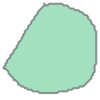

In [28]:
# Visualization
# z = 0
# x_points = cell_boundaries_train_df.iloc[0, 1 + z * 2]
# y_points = cell_boundaries_train_df.iloc[0, 2 + z * 2]
# plt.plot(x_points, y_points) # Cool!
# plt.show()

# Visualization
# points_z0 = list(zip(cell_boundaries_train_df.iloc[0, 1], cell_boundaries_train_df.iloc[0, 2]))
# Polygon(points_z0)

# Visualization
polygon_df['polygon_z0'][300]

In [29]:
polygon_df.head()

,Unnamed: 0,polygon_z0,polygon_z1,polygon_z2,polygon_z3,polygon_z4
0,267725525651232306728125526231708191,POLYGON ((-1343.5731309860944 -474.12199974060...,POLYGON ((-1343.5731309860944 -473.90399974584...,POLYGON ((-1343.6821309834718 -473.03199976682...,POLYGON ((-1343.7911309808492 -474.01299974322...,POLYGON ((-1343.7911309808492 -473.14099976420...
1,327375991457903881984615241423065475,POLYGON ((2189.4068658143283 -1787.90306285023...,POLYGON ((2189.624865809083 -1789.211062818765...,POLYGON ((2189.4068658143283 -1788.66606283187...,POLYGON ((2189.4068658143283 -1788.77506282925...,POLYGON ((2189.624865809083 -1788.448062837123...
2,364755379140285267217928676041057312,POLYGON ((-1336.3791311591863 -533.74499830603...,POLYGON ((-1336.7061311513185 -533.74499830603...,POLYGON ((-1334.5261312037705 -531.67399835586...,POLYGON ((-1333.3271312326192 -531.56499835848...,POLYGON ((-1333.2181312352418 -531.12899836897...
3,377956362916104527021675785082246047,POLYGON ((174.90989572703836 2337.431938946247...,POLYGON ((174.58289573490617 2338.630938917398...,"POLYGON ((174.255895742774 2338.3039389252663,...",POLYGON ((173.8198957532644 2337.3229389488697...,"POLYGON ((173.8198957532644 2337.431938946247,..."
4,429470755737170534203514668497237885,POLYGON ((-1013.4271341174841 -573.95100215077...,POLYGON ((-1012.010134151578 -572.970002174377...,POLYGON ((-1012.7731341332197 -573.07900217175...,POLYGON ((-1012.7731341332197 -573.29700216650...,POLYGON ((-1012.7731341332197 -573.84200215339...


### Submission

In [30]:
# NOTE: Original version, DEPRICATED

# WE ITERATE ACROSS ALL SPOTS DETECTED (MASK) FIRST 
# submission_df = []
# for s in tqdm(range(spots_train_df.shape[0])):
#     spot_row = spots_train_df.iloc[s, :]
#     global_x = int(spot_row['global_x'])
#     global_y = int(spot_row['global_y'])
#     global_z = int(spot_row['global_z'])

#     submission_row = {
#         'spot_id' : s,
#         'fov' : spot_row['fov'],
#         'gt_cluster_id' : 'background'
#     }

#     for cell in tqdm(range(polygon_df.shape[0]), leave=False, disable=True):
#         cell_row = polygon_df.loc[cell, :]

#             # if there is an NA, then the cell is not on this z-plane, skip
#         if not cell_row[f"polygon_z{global_z}"]:
#             continue

#         if (cell_row[f"polygon_z{global_z}"].contains(Point((global_x, global_y) ))):
#             submission_row['gt_cluster_id'] = cell_row["Unnamed: 0"]
#             break

#     submission_df.append(submission_row)

# submission_df = pd.DataFrame(submission_df)
# submission_df

In [ ]:
# Claude Optimization
# https://claude.ai/share/db1c3b53-241d-4d0e-9222-abd4566a4d89
from shapely.strtree import STRtree
from shapely.geometry import Point
from tqdm import tqdm
import pandas as pd
import numpy as np

def assign_spots_to_cells(spots_train_df, polygon_df):
    rows = []

    # Pre-compute unique z-planes to avoid repeated string formatting
    # z_planes = spots_train_df['global_z'].unique()
    # print("z_planes", z_planes)
    # return

    # Pre-build spatial index per z-plane: {z: (STRtree, list of cell ids)}
    spatial_index = {}
    # for z in z_planes:
    for z in range(0, 5):
        col = f"polygon_z{z}"
        # if col not in polygon_df.columns:
        #     continue

        # Only keep rows where polygon is not null/falsy for this z
        valid = polygon_df[polygon_df[col].notna() & polygon_df[col].astype(bool)]
        if valid.empty:
            continue

        polygons = valid[col].tolist()
        cell_ids = valid["Unnamed: 0"].tolist()
        tree = STRtree(polygons)
        spatial_index[z] = (tree, polygons, cell_ids)

    # Main loop — now O(n log m) instead of O(n*m)
    for s, spot_row in enumerate(tqdm(spots_train_df.itertuples(), total=len(spots_train_df))):
        global_x = int(spot_row.global_x)
        global_y = int(spot_row.global_y)
        global_z = int(spot_row.global_z)

        gt_cluster_id = 'background'

        if global_z in spatial_index:
            tree, polygons, cell_ids = spatial_index[global_z]
            point = Point(global_x, global_y)

            # Query returns indices of candidate polygons (bounding box hit)
            candidates = tree.query(point)
            for idx in candidates:
                if polygons[idx].contains(point):
                    gt_cluster_id = cell_ids[idx]
                    break

        rows.append({
            'spot_id': s,
            'fov': spot_row.fov,
            'image_row': spot_row.image_row,
            'image_col': spot_row.image_col,
            'global_x': spot_row.global_x,
            'global_y': spot_row.global_y,
            'global_z': spot_row.global_z,
            'gt_cluster_id': gt_cluster_id,
        })

    return pd.DataFrame(rows)

train_solution_df = assign_spots_to_cells(spots_train_df, polygon_df)

  0%|          | 0/2659359 [00:00<?, ?it/s]

100%|██████████| 2659359/2659359 [00:22<00:00, 118140.50it/s]


In [32]:
train_solution_df.head()

,spot_id,fov,image_row,image_col,global_x,global_y,global_z,gt_cluster_id
0,0,FOV_019,1468,1575,5649.4106,-393.08737,0.0,background
1,1,FOV_019,303,1800,5776.4834,-368.60250,0.0,background
2,2,FOV_019,749,579,5727.8633,-501.73105,0.0,background
3,3,FOV_019,1100,704,5689.5854,-488.09860,0.0,background
4,4,FOV_019,522,118,5752.5440,-551.92944,0.0,background


In [33]:
spots_train_df.head()

,fov,image_row,image_col,global_x,global_y,global_z
0,FOV_019,1468,1575,5649.4106,-393.08737,0.0
1,FOV_019,303,1800,5776.4834,-368.60250,0.0
2,FOV_019,749,579,5727.8633,-501.73105,0.0
3,FOV_019,1100,704,5689.5854,-488.09860,0.0
4,FOV_019,522,118,5752.5440,-551.92944,0.0


In [34]:
train_solution_df.to_csv(RESULTS / 'spots_train_w_cell_id_solution.csv')

In [35]:
# train_solution_df[(train_solution_df['fov'] == 'FOV_019') & (train_solution_df['global_z'] == 2.0)]